# Analysis of InfoGap's annotations of WikiMT data

**Setup Instructions:**
1. Update the paths and parameters in the **Configuration cell** below to match your environment
2. Ensure all required data files are available at the specified paths
3. Run cells in order from top to bottom

In [33]:
# ==============================================================================
# CONFIGURATION - Update these paths for your environment
# ==============================================================================
import os

# --- Data Paths ---
INFOGAP_DIR = "/Users/llupo/dev/infogap"
WIKIMT_DIR = "/Users/llupo/dev/wiki_mt"


# InfoGap annotations directory (contains annotation_*.json files)
ANNOTATIONS_DIR = os.path.join(INFOGAP_DIR, "scratch/annotation_save/wikigap_data")

# InfoGap sample file (contains QIDs and group labels for the analyzed articles)
INFOGAP_SAMPLE_FILE = os.path.join(INFOGAP_DIR, "scratch/sampled_combined_fr_n510.pkl")

# Wiki_MT divergence analysis directory and files
WIKIMT_DIV_TREAT = os.path.join(WIKIMT_DIR, "data/outputs/divergence_analysis/article_divergence_fr_treatment.parquet")
WIKIMT_DIV_CONTROL = os.path.join(WIKIMT_DIR, "data/outputs/divergence_analysis/article_divergence_fr_control.parquet")

# --- Analysis Parameters ---
# Statistical significance level
ALPHA = 0.05

# Minimum observations per arm for treatment effect estimation
MIN_PER_ARM = 3

# Language codes
SOURCE_LANG = "en"  # Source language
TARGET_LANG = "fr"  # Target language

## Compute Symmetric Reference Divergence

For each article pair, we compute a **symmetric reference divergence** metric based on the yes/no intersection labels from the InfoGap pipeline:

$$D_{\text{yes/no}} = 1 - \frac{Y_S + Y_T}{F_S + F_T}$$

Where:
- $F_S$ = number of facts in source article
- $F_T$ = number of facts in target article  
- $Y_S$ = number of source facts present in target (sum of yes labels)
- $Y_T$ = number of target facts present in source (sum of yes labels)

**Interpretation**: This measures the fraction of facts that are *unmatched* across both sides. A value of 0 means perfect overlap; 1 means no overlap.

In [34]:
import os
import json
import pandas as pd
from pathlib import Path
from collections import defaultdict

# ==============================================================================
# STEP 1: Load annotation files and detect duplicates
# ==============================================================================

annotation_files = list(Path(ANNOTATIONS_DIR).glob("annotation_*.json"))

print(f"Found {len(annotation_files)} total annotation files\n")

# Group files by article name (extract from filename)
# Filename format: annotation_YYYY-MM-DD_ArticleName_lang.json
article_files = defaultdict(list)

for f in annotation_files:
    # Parse filename: annotation_2025-10-27_Article Name_fr.json
    # Strategy: split by '_', extract date (position 1), and reconstruct article name
    parts = f.stem.split('_')
    
    if len(parts) >= 3:
        date = parts[1]  # '2025-10-27'
        lang = parts[-1]  # 'fr' or 'en'
        
        # Article name is everything between date and language
        article_name_parts = parts[2:-1]
        article_name = '_'.join(article_name_parts)
        
        # Use article name + language as unique key
        unique_key = f"{article_name}_{lang}"
        
        article_files[unique_key].append((date, f))

# Count unique articles (ignoring language suffix)
unique_articles = set()
for key in article_files.keys():
    article_base = '_'.join(key.split('_')[:-1]) if '_' in key else key
    unique_articles.add(article_base)

print(f"Found {len(unique_articles)} unique articles ({len(article_files)} article-language pairs)")

# ==============================================================================
# STEP 2: Remove duplicates (keep most recent)
# ==============================================================================

duplicates_found = 0
files_to_remove = []

for article_key, files in article_files.items():
    if len(files) > 1:
        duplicates_found += 1
        # Sort by date (descending) to keep the most recent
        files.sort(reverse=True)
        most_recent = files[0]
        older_files = files[1:]
        
        print(f"\n  Duplicate: {article_key}")
        print(f"    ✓ Keeping:  {most_recent[1].name} ({most_recent[0]})")
        for date, f in older_files:
            print(f"    ✗ Removing: {f.name} ({date})")
            files_to_remove.append(f)

if files_to_remove:
    print(f"\n{'='*70}")
    print(f"Found {len(files_to_remove)} duplicate files - removing them...")
    print(f"{'='*70}\n")
    
    for f in files_to_remove:
        f.unlink()
        print(f"  Deleted: {f.name}")
    
    print(f"\n✓ Cleanup complete! Removed {len(files_to_remove)} files.")
    
    # Refresh file list after deletion
    annotation_files = list(annotation_dir.glob("annotation_*.json"))
    print(f"✓ {len(annotation_files)} files remaining\n")
else:
    print("\n✓ No duplicate files found!\n")

# ==============================================================================
# STEP 3: Load annotation files into DataFrames
# ==============================================================================

print(f"{'='*70}")
print("Loading annotation files...")
print(f"{'='*70}\n")

output_dfs = []

for ann_file in annotation_files:
    try:
        with open(ann_file, 'r') as f:
            data = json.load(f)
        
        # Parse the Polars JSON structure
        columns_data = {}
        for col in data['columns']:
            col_name = col['name']
            values = col['values']
            
            # Handle nested list structures
            if col['datatype'] == {'List': 'Utf8'} or \
               col['datatype'] == {'List': {'List': 'Utf8'}} or \
               col['datatype'] == {'List': 'Float64'}:
                columns_data[col_name] = values
            else:
                columns_data[col_name] = values
        
        # Create DataFrame with key columns
        df = pd.DataFrame({
            'fact': columns_data['fact'],
            'person_name': columns_data['person_name'],
            'language': columns_data['language'],
            'intersection_label': columns_data['intersection_label']
        })
        
        # Store filename for reference
        df.attrs['filename'] = ann_file.name
        
        output_dfs.append(df)
        
    except Exception as e:
        print(f"  ✗ Error loading {ann_file.name}: {e}")
        continue

print(f"✓ Successfully loaded {len(output_dfs)} annotation files\n")

# ==============================================================================
# STEP 4: Compute divergence for each article pair
# ==============================================================================

print(f"{'='*70}")
print("Computing reference divergence...")
print(f"{'='*70}\n")

def compute_reference_divergence(df, min_facts=6):
    """
    Compute symmetric reference divergence for an article pair.
    
    Returns dict with divergence metrics.
    """
    # Identify source and target languages
    languages = df['language'].unique()
    if len(languages) != 2:
        return {
            'divergence': None,
            'F_S': 0, 'F_T': 0, 'Y_S': 0, 'Y_T': 0,
            'excluded': True,
            'reason': f'Expected 2 languages, found {len(languages)}'
        }
    
    src_lang, tgt_lang = languages[0], languages[1]
    
    # Get source and target subsets
    df_src = df[df['language'] == src_lang]
    df_tgt = df[df['language'] == tgt_lang]
    
    # Count facts
    F_S = len(df_src)
    F_T = len(df_tgt)
    
    # Check minimum threshold
    if F_S + F_T < min_facts:
        return {
            'divergence': None,
            'F_S': F_S, 'F_T': F_T, 'Y_S': 0, 'Y_T': 0,
            'excluded': True,
            'reason': f'Too few facts: F_S + F_T = {F_S + F_T} < {min_facts}'
        }
    
    # Count matches (yes labels)
    def count_yes(labels_series):
        count = 0
        for label in labels_series:
            if isinstance(label, str):
                label_lower = label.lower().strip()
                if label_lower == 'yes' or label_lower == 'y':
                    count += 1
        return count
    
    Y_S = count_yes(df_src['intersection_label'])
    Y_T = count_yes(df_tgt['intersection_label'])
    
    # Compute divergence
    divergence = 1 - (Y_S + Y_T) / (F_S + F_T)
    
    return {
        'divergence': divergence,
        'F_S': F_S,
        'F_T': F_T,
        'Y_S': Y_S,
        'Y_T': Y_T,
        'excluded': False,
        'reason': None,
        'src_lang': src_lang,
        'tgt_lang': tgt_lang
    }

# Compute divergence for each article pair
divergence_results = []

for i, df in enumerate(output_dfs):
    result = compute_reference_divergence(df, min_facts=6)
    
    # Get article name
    if 'person_name' in df.columns:
        person_names = df['person_name'].unique()
        article_name = person_names[0] if len(person_names) > 0 else f'Article_{i}'
    else:
        article_name = f'Article_{i}'
    
    result['article'] = article_name
    result['filename'] = df.attrs.get('filename', f'unknown_{i}')
    divergence_results.append(result)
    
    # Print result
    if result['excluded']:
        print(f"⚠️  {article_name}: EXCLUDED - {result['reason']}")
    else:
        src_lang = result.get('src_lang', 'src')
        tgt_lang = result.get('tgt_lang', 'tgt')
        print(f"✓ {article_name} ({src_lang}↔{tgt_lang}):")
        print(f"  D_yes/no = {result['divergence']:.3f}")
        print(f"  Facts: F_{src_lang}={result['F_S']}, F_{tgt_lang}={result['F_T']}")
        print(f"  Matched: Y_{src_lang}={result['Y_S']}, Y_{tgt_lang}={result['Y_T']}")
        if result['F_S'] > 0 and result['F_T'] > 0:
            print(f"  Recall_{src_lang}={result['Y_S']/result['F_S']:.2%}, "
                  f"Recall_{tgt_lang}={result['Y_T']/result['F_T']:.2%}")
        print()

# ==============================================================================
# STEP 5: Create summary DataFrame
# ==============================================================================

infogap_div_df = pd.DataFrame(divergence_results)

print("\n" + "="*70)
print("SUMMARY")
print("="*70)
display_cols = ['article', 'divergence', 'F_S', 'F_T', 'Y_S', 'Y_T', 'excluded']
print(infogap_div_df[display_cols].to_string(index=False))

non_excluded = infogap_div_df[~infogap_div_df['excluded']]
if len(non_excluded) > 0:
    print(f"\nStatistics (non-excluded articles):")
    print(f"  Count: {len(non_excluded)}")
    print(f"  Mean divergence: {non_excluded['divergence'].mean():.3f}")
    print(f"  Median divergence: {non_excluded['divergence'].median():.3f}")
    print(f"  Min divergence: {non_excluded['divergence'].min():.3f}")
    print(f"  Max divergence: {non_excluded['divergence'].max():.3f}")
    print(f"  Std divergence: {non_excluded['divergence'].std():.3f}")
else:
    print("\n⚠️  No valid article pairs to compute statistics")

# Display the DataFrame
infogap_div_df.head(3)


Found 489 total annotation files

Found 489 unique articles (489 article-language pairs)

✓ No duplicate files found!

Loading annotation files...

✓ Successfully loaded 489 annotation files

Computing reference divergence...

✓ Jacques Marie Boudin de Tromelin de La Nuguy (fr↔en):
  D_yes/no = 0.776
  Facts: F_fr=50, F_en=84
  Matched: Y_fr=12, Y_en=18
  Recall_fr=24.00%, Recall_en=21.43%

✓ Nicolas Alexandre Barbier (fr↔en):
  D_yes/no = 0.724
  Facts: F_fr=20, F_en=9
  Matched: Y_fr=5, Y_en=3
  Recall_fr=25.00%, Recall_en=33.33%

✓ Éric Vandenabeele (fr↔en):
  D_yes/no = 0.455
  Facts: F_fr=23, F_en=10
  Matched: Y_fr=11, Y_en=7
  Recall_fr=47.83%, Recall_en=70.00%

✓ The Great Ghost Rescue (film) (en↔fr):
  D_yes/no = 0.667
  Facts: F_en=20, F_fr=4
  Matched: Y_en=4, Y_fr=4
  Recall_en=20.00%, Recall_fr=100.00%

✓ Joseph Brummer (fr↔en):
  D_yes/no = 0.019
  Facts: F_fr=26, F_en=27
  Matched: Y_fr=25, Y_en=27
  Recall_fr=96.15%, Recall_en=100.00%

✓ Louis du Couret (en↔fr):
  D_yes

,divergence,F_S,F_T,Y_S,Y_T,excluded,reason,src_lang,tgt_lang,article,filename
0,0.776119,50,84,12,18,False,None,fr,en,Jacques Marie Boudin de Tromelin de La Nuguy,annotation_2025-11-10_Jacques Marie Boudin de ...
1,0.724138,20,9,5,3,False,None,fr,en,Nicolas Alexandre Barbier,annotation_2025-11-11_Nicolas Alexandre Barbie...
2,0.454545,23,10,11,7,False,None,fr,en,Éric Vandenabeele,annotation_2025-11-10_Éric Vandenabeele_fr.json


## Match InfoGap Articles with Wiki_MT Groups

This section:
1. Loads the InfoGap sample file (contains QIDs and group labels)
2. Loads Wiki_MT treatment and control divergence parquet files
3. Uses QID-based matching to assign each InfoGap article to treatment/control group
4. Verifies matching consistency and completeness

In [36]:
# ==============================================================================
# Match InfoGap Articles with Wiki_MT Groups using QID
# ==============================================================================

# Load InfoGap sample file (contains QID and group labels)
infogap_sample = pd.read_pickle(INFOGAP_SAMPLE_FILE)

print(f"InfoGap sample loaded: {len(infogap_sample)} articles")
print(f"  Treatment: {(infogap_sample['group'] == 'treatment').sum()}")
print(f"  Control: {(infogap_sample['group'] == 'control').sum()}")

# Create mapping from article title (person_name in annotations) to QID and group
title_to_qid = dict(zip(infogap_sample['sourceTitle'], infogap_sample['qid']))
title_to_group = dict(zip(infogap_sample['sourceTitle'], infogap_sample['group']))

print(f"\nCreated title→QID mapping for {len(title_to_qid)} articles")

# Load Wiki_MT parquet files
df_fr_treatment = pd.read_parquet(WIKIMT_DIV_TREAT)
df_fr_control = pd.read_parquet(WIKIMT_DIV_CONTROL)

print(f"\nWiki_MT data loaded:")
print(f"  Treatment articles: {len(df_fr_treatment)}")
print(f"  Control articles: {len(df_fr_control)}")

# Get QID sets from Wiki_MT
treatment_qids = set(df_fr_treatment['qid'].dropna())
control_qids = set(df_fr_control['qid'].dropna())

print(f"\nWiki_MT QIDs:")
print(f"  Treatment: {len(treatment_qids)} unique QIDs")
print(f"  Control: {len(control_qids)} unique QIDs")

# Map InfoGap articles to groups using QID-based matching
def map_article_to_group(article_name):
    """Map article name to group via QID lookup in Wiki_MT"""
    # Get QID from sample file
    qid = title_to_qid.get(article_name)
    
    if qid is None:
        return None  # Article not in sample
    
    # Check which Wiki_MT group contains this QID
    if qid in treatment_qids:
        return 'treatment'
    elif qid in control_qids:
        return 'control'
    else:
        return None  # QID not found in Wiki_MT

# Apply mapping
infogap_div_df['wikimt_group'] = infogap_div_df['article'].apply(map_article_to_group)
infogap_div_df['qid'] = infogap_div_df['article'].map(title_to_qid)
infogap_div_df['expected_group'] = infogap_div_df['article'].map(title_to_group)

# Verify matching results
print(f"\n{'='*80}")
print("QID-BASED MATCHING RESULTS")
print(f"{'='*80}")
print(f"\nInfoGap articles analyzed: {len(infogap_div_df)}")
print(f"Matched to treatment: {(infogap_div_df['wikimt_group'] == 'treatment').sum()}")
print(f"Matched to control: {(infogap_div_df['wikimt_group'] == 'control').sum()}")
print(f"Unmatched: {infogap_div_df['wikimt_group'].isna().sum()}")

# Verify group consistency (expected vs actual)
matched = infogap_div_df[infogap_div_df['wikimt_group'].notna()]
if len(matched) > 0:
    consistent = (matched['wikimt_group'] == matched['expected_group']).sum()
    print(f"\nGroup label consistency: {consistent}/{len(matched)} ({consistent/len(matched)*100:.1f}%)")
    
    if consistent != len(matched):
        print("\n⚠️  WARNING: Some articles have mismatched group labels!")
        mismatched = matched[matched['wikimt_group'] != matched['expected_group']]
        print(f"Mismatched articles: {len(mismatched)}")
        for idx, row in mismatched.head(5).iterrows():
            print(f"  - {row['article']}: Expected={row['expected_group']}, Found={row['wikimt_group']}")
    else:
        print("✅ All matched articles have consistent group labels!")

# Show unmatched articles (if any)
unmatched = infogap_div_df[infogap_div_df['wikimt_group'].isna()]['article'].tolist()
if unmatched:
    print(f"\n⚠️  Unmatched articles ({len(unmatched)}):")
    for art in unmatched[:10]:
        qid = title_to_qid.get(art, 'No QID')
        print(f"  - {art} (QID: {qid})")
    if len(unmatched) > 10:
        print(f"  ... and {len(unmatched) - 10} more")
else:
    print(f"\n✅ Perfect matching: All {len(infogap_div_df)} articles matched successfully!")

# Summary by group
print(f"\n{'='*80}")
print("SUMMARY BY GROUP")
print(f"{'='*80}")
for group in ['treatment', 'control']:
    group_df = infogap_div_df[infogap_div_df['wikimt_group'] == group]
    if len(group_df) > 0:
        print(f"\n{group.upper()} (n={len(group_df)}):")
        print(f"  Mean divergence: {group_df['divergence'].mean():.4f}")
        print(f"  Median divergence: {group_df['divergence'].median():.4f}")
        print(f"  Std: {group_df['divergence'].std():.4f}")

InfoGap sample loaded: 504 articles
  Treatment: 249
  Control: 255

Created title→QID mapping for 504 articles

Wiki_MT data loaded:
  Treatment articles: 75784
  Control articles: 75784

Wiki_MT QIDs:
  Treatment: 75508 unique QIDs
  Control: 75674 unique QIDs

QID-BASED MATCHING RESULTS

InfoGap articles analyzed: 489
Matched to treatment: 235
Matched to control: 254
Unmatched: 0

Group label consistency: 489/489 (100.0%)
✅ All matched articles have consistent group labels!

✅ Perfect matching: All 489 articles matched successfully!

SUMMARY BY GROUP

TREATMENT (n=235):
  Mean divergence: 0.2695
  Median divergence: 0.2000
  Std: 0.2043

CONTROL (n=254):
  Mean divergence: 0.5586
  Median divergence: 0.5971
  Std: 0.2282


In [37]:
# Refresh comparison_df with the new matching results
comparison_df = infogap_div_df[infogap_div_df['wikimt_group'].notna()].copy()

print(f"✅ Updated comparison_df:")
print(f"   Total: {len(comparison_df)}")
print(f"   Treatment: {(comparison_df['wikimt_group'] == 'treatment').sum()}")
print(f"   Control: {(comparison_df['wikimt_group'] == 'control').sum()}")

✅ Updated comparison_df:
   Total: 489
   Treatment: 235
   Control: 254


## Statistical Test: Treatment vs Control Groups

Test whether InfoGap divergence differs significantly between treatment and control groups.


Visualizing Treatment vs Control



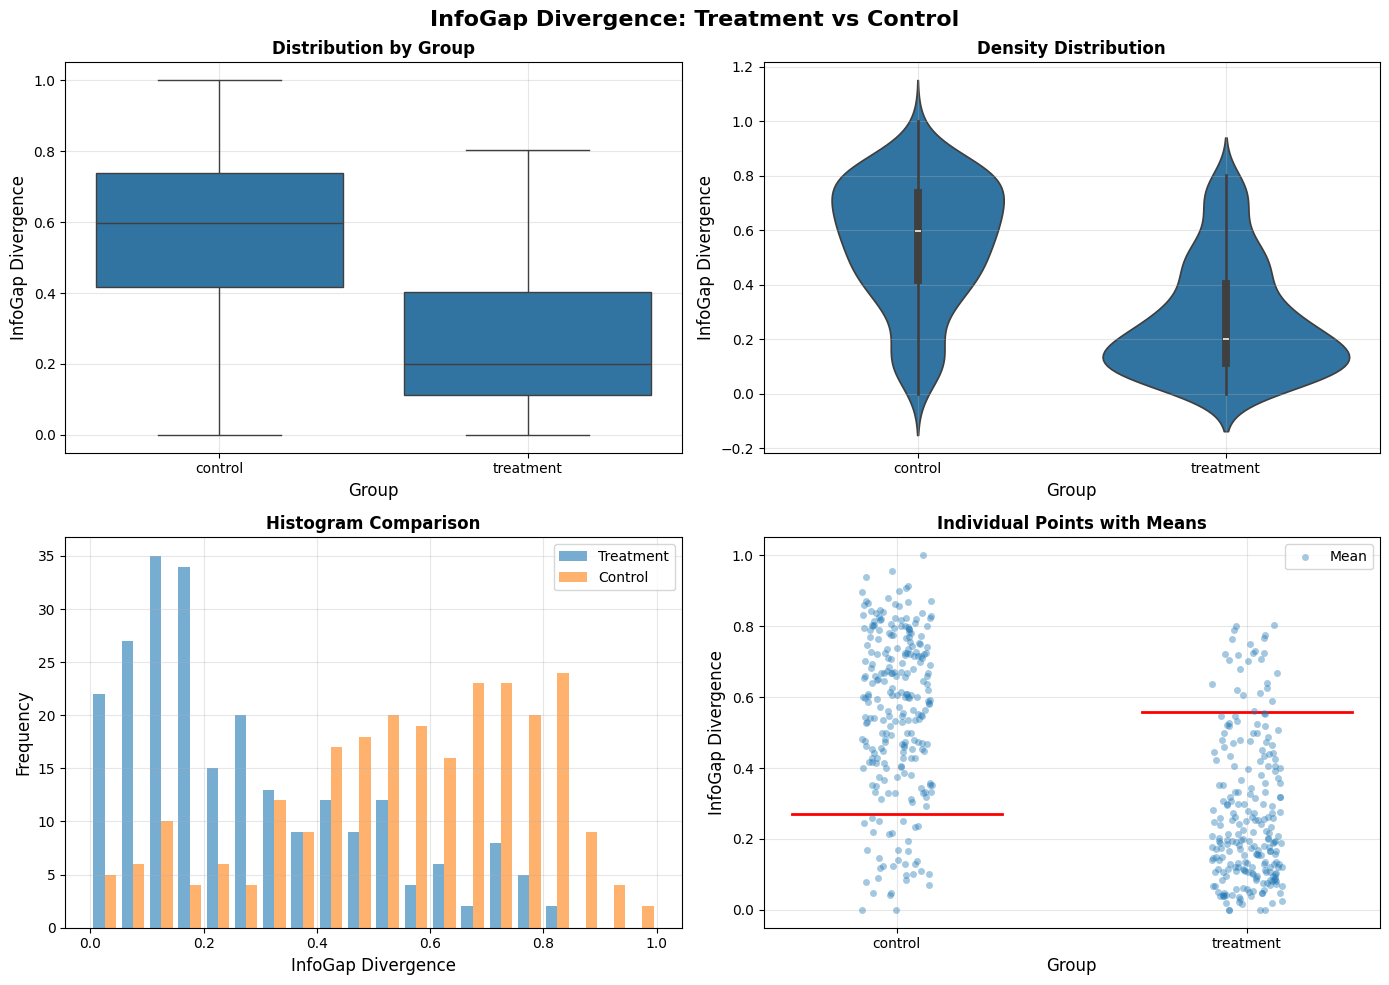

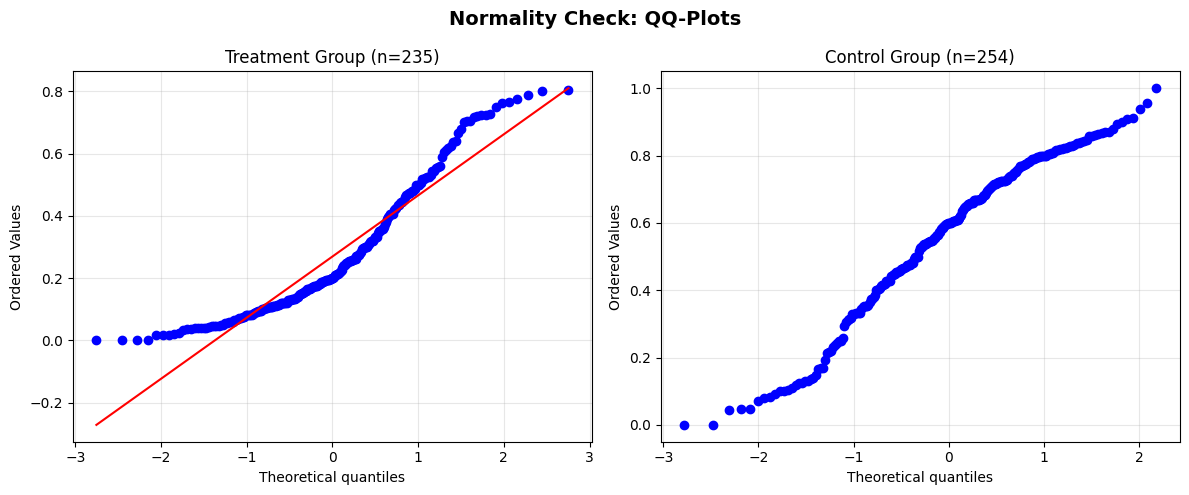

In [38]:
# ==============================================================================
# Visualize Treatment vs Control Divergence
# ==============================================================================

import matplotlib.pyplot as plt
import seaborn as sns

# Check if we have both groups
n_treatment = (comparison_df['wikimt_group'] == 'treatment').sum()
n_control = (comparison_df['wikimt_group'] == 'control').sum()

if n_treatment > 0 and n_control > 0:
    print(f"\n{'='*80}")
    print("Visualizing Treatment vs Control")
    print(f"{'='*80}\n")
    
    # Create figure with multiple subplots
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    fig.suptitle('InfoGap Divergence: Treatment vs Control', fontsize=16, fontweight='bold')
    
    # 1. Box plot
    ax = axes[0, 0]
    sns.boxplot(data=comparison_df, x='wikimt_group', y='divergence', ax=ax)
    ax.set_xlabel('Group', fontsize=12)
    ax.set_ylabel('InfoGap Divergence', fontsize=12)
    ax.set_title('Distribution by Group', fontsize=12, fontweight='bold')
    ax.grid(True, alpha=0.3)
    
    # 2. Violin plot
    ax = axes[0, 1]
    sns.violinplot(data=comparison_df, x='wikimt_group', y='divergence', ax=ax)
    ax.set_xlabel('Group', fontsize=12)
    ax.set_ylabel('InfoGap Divergence', fontsize=12)
    ax.set_title('Density Distribution', fontsize=12, fontweight='bold')
    ax.grid(True, alpha=0.3)
    
    # 3. Histogram
    ax = axes[1, 0]
    treatment_div = comparison_df[comparison_df['wikimt_group'] == 'treatment']['divergence']
    control_div = comparison_df[comparison_df['wikimt_group'] == 'control']['divergence']
    
    ax.hist([treatment_div, control_div], bins=20, alpha=0.6, label=['Treatment', 'Control'])
    ax.set_xlabel('InfoGap Divergence', fontsize=12)
    ax.set_ylabel('Frequency', fontsize=12)
    ax.set_title('Histogram Comparison', fontsize=12, fontweight='bold')
    ax.legend()
    ax.grid(True, alpha=0.3)
    
    # 4. Strip plot with means
    ax = axes[1, 1]
    sns.stripplot(data=comparison_df, x='wikimt_group', y='divergence', alpha=0.4, ax=ax)
    
    # Add mean lines
    for group in ['treatment', 'control']:
        group_mean = comparison_df[comparison_df['wikimt_group'] == group]['divergence'].mean()
        x_pos = 0 if group == 'treatment' else 1
        ax.plot([x_pos - 0.3, x_pos + 0.3], [group_mean, group_mean], 
                color='red', linewidth=2, label=f'{group.capitalize()} mean' if group == 'treatment' else None)
    
    ax.set_xlabel('Group', fontsize=12)
    ax.set_ylabel('InfoGap Divergence', fontsize=12)
    ax.set_title('Individual Points with Means', fontsize=12, fontweight='bold')
    ax.legend(['Mean'], loc='upper right')
    ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    # Additional: QQ-plot to check normality
    from scipy import stats
    
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    fig.suptitle('Normality Check: QQ-Plots', fontsize=14, fontweight='bold')
    
    for i, group in enumerate(['treatment', 'control']):
        group_data = comparison_df[comparison_df['wikimt_group'] == group]['divergence']
        stats.probplot(group_data, dist="norm", plot=axes[i])
        axes[i].set_title(f'{group.capitalize()} Group (n={len(group_data)})', fontsize=12)
        axes[i].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

elif n_treatment > 0:
    print(f"\n⚠️  Only treatment group available - showing treatment distribution only")
    
    fig, ax = plt.subplots(1, 1, figsize=(10, 6))
    treatment_div = comparison_df[comparison_df['wikimt_group'] == 'treatment']['divergence']
    
    ax.hist(treatment_div, bins=20, alpha=0.7, edgecolor='black')
    ax.axvline(treatment_div.mean(), color='red', linestyle='--', linewidth=2, label=f'Mean: {treatment_div.mean():.3f}')
    ax.axvline(treatment_div.median(), color='blue', linestyle='--', linewidth=2, label=f'Median: {treatment_div.median():.3f}')
    ax.set_xlabel('InfoGap Divergence', fontsize=12)
    ax.set_ylabel('Frequency', fontsize=12)
    ax.set_title(f'Treatment Group Distribution (n={len(treatment_div)})', fontsize=14, fontweight='bold')
    ax.legend()
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
    
else:
    print(f"\n❌ No data available for visualization")

TREATMENT EFFECT ESTIMATION: INFOGAP DIVERGENCE

Sample sizes:
  Treatment: n = 235
  Control:   n = 251

OLS REGRESSION ESTIMATION

Formula: divergence ~ group + log_facts_c

                            OLS Regression Results                            
Dep. Variable:             divergence   R-squared:                       0.330
Model:                            OLS   Adj. R-squared:                  0.327
Method:                 Least Squares   F-statistic:                     121.0
Date:                Thu, 13 Nov 2025   Prob (F-statistic):           2.49e-43
Time:                        15:35:38   Log-Likelihood:                 61.882
No. Observations:                 486   AIC:                            -117.8
Df Residuals:                     483   BIC:                            -105.2
Df Model:                           2                                         
Covariance Type:                  HC3                                         
                         coef    s

/var/folders/hh/rjqw1xv93s516zyl87hymmr80000gn/T/ipykernel_24597/4291318797.py:197: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax2.boxplot([treat_vals, control_vals],
/var/folders/hh/rjqw1xv93s516zyl87hymmr80000gn/T/ipykernel_24597/4291318797.py:213: UserWarning: Glyph 65290 (\N{FULLWIDTH ASTERISK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/Users/llupo/miniconda3/envs/mentalenv/lib/python3.10/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 65290 (\N{FULLWIDTH ASTERISK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


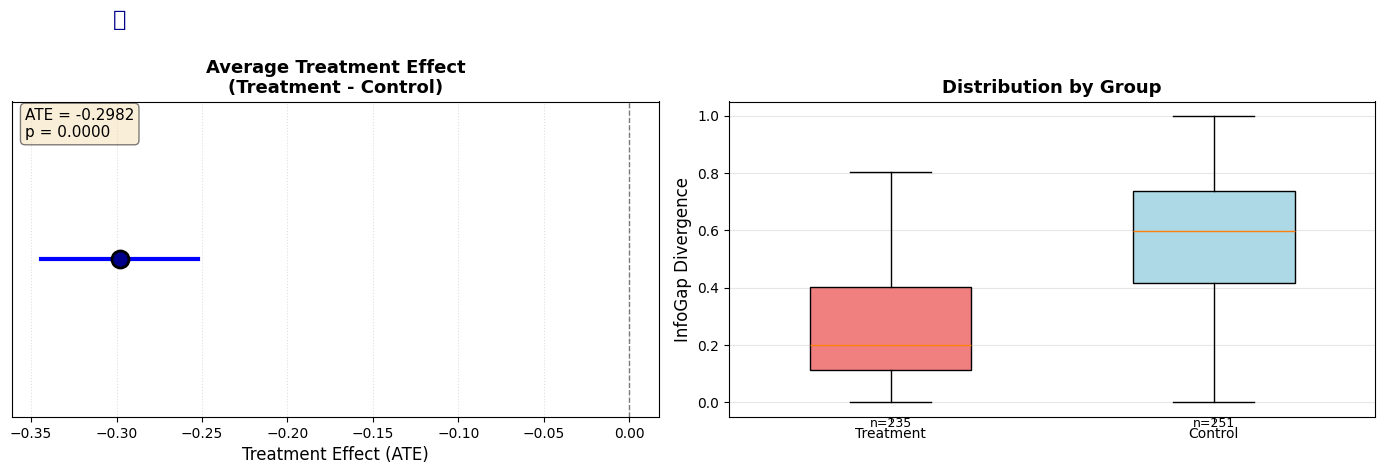

In [39]:
# ==============================================================================
# Treatment Effect Estimation: InfoGap Divergence (OLS Regression Framework)
# ==============================================================================

import pandas as pd
import numpy as np
from scipy import stats
import statsmodels.formula.api as smf
import matplotlib.pyplot as plt
import seaborn as sns

print("="*80)
print("TREATMENT EFFECT ESTIMATION: INFOGAP DIVERGENCE")
print("="*80)

# -----------------------------------------------------------------------------
# 1. Check data availability
# -----------------------------------------------------------------------------
if 'wikimt_group' not in comparison_df.columns:
    print("\n⚠️  ERROR: No group information available")
    print("Available columns:", comparison_df.columns.tolist())
    print("\nTo perform treatment effect estimation, you need:")
    print("  1. A 'wikimt_group' column with 'treatment' and 'control' labels")
    print("  2. Both treatment and control articles in your comparison_df")
    print("\nCurrent situation: comparison_df only contains articles from one source.")
    print("You need to run the InfoGap pipeline on BOTH treatment and control articles.")
    
else:
    # Prepare data
    df_model = comparison_df.dropna(subset=['divergence']).copy()
    df_model['group'] = df_model['wikimt_group'].astype('category')
    
    n_treat = (df_model['group'] == 'treatment').sum()
    n_control = (df_model['group'] == 'control').sum()
    
    print(f"\nSample sizes:")
    print(f"  Treatment: n = {n_treat}")
    print(f"  Control:   n = {n_control}")
    
    if n_control == 0:
        print(f"\n{'='*80}")
        print("⚠️  INSUFFICIENT DATA FOR TREATMENT EFFECT ESTIMATION")
        print(f"{'='*80}")
        print("\nYou have ZERO control group articles!")
        print("\nTo estimate treatment effects, you need:")
        print("  - At least 3 treatment articles (you have: {})".format(n_treat))
        print("  - At least 3 control articles (you have: 0)")
        print("\nNext steps:")
        print("  1. Sample control group articles from your wiki_mt data")
        print("  2. Run the InfoGap pipeline on those articles")
        print("  3. Merge the results into comparison_df with group='control'")
        print("  4. Re-run this cell")
        
        print(f"\n{'='*80}")
        print("DESCRIPTIVE STATISTICS (Treatment only)")
        print(f"{'='*80}")
        treat_div = df_model[df_model['group']=='treatment']['divergence']
        print(f"\nTreatment Group:")
        print(f"  Mean:   {treat_div.mean():.4f}")
        print(f"  Median: {treat_div.median():.4f}")
        print(f"  Std:    {treat_div.std():.4f}")
        print(f"  Min:    {treat_div.min():.4f}")
        print(f"  Max:    {treat_div.max():.4f}")
        
    elif min(n_treat, n_control) < MIN_PER_ARM:
        print(f"\n⚠️  WARNING: Sample size too small for reliable estimation")
        print(f"   Minimum required per arm: {MIN_PER_ARM}")
        print(f"   Proceeding with caution...")
        
        # Simple comparison (no covariates)
        print(f"\n{'='*80}")
        print("SIMPLE COMPARISON (No Covariates)")
        print(f"{'='*80}")
        
        treat_div = df_model[df_model['group']=='treatment']['divergence']
        control_div = df_model[df_model['group']=='control']['divergence']
        
        print(f"\nTreatment: Mean = {treat_div.mean():.4f}, SD = {treat_div.std():.4f}")
        print(f"Control:   Mean = {control_div.mean():.4f}, SD = {control_div.std():.4f}")
        print(f"\nNaive difference: {treat_div.mean() - control_div.mean():.4f}")
        
        # T-test
        t_stat, p_val = stats.ttest_ind(treat_div, control_div)
        print(f"\nT-test: t = {t_stat:.3f}, p = {p_val:.4f}")
        
        if p_val < ALPHA:
            print(f"  Result: * SIGNIFICANT at α={ALPHA}")
        else:
            print(f"  Result: NOT SIGNIFICANT at α={ALPHA}")
    
    else:
        # ---------------------------------------------------------------------
        # 2. Sufficient data: run OLS regression
        # ---------------------------------------------------------------------
        print(f"\n{'='*80}")
        print("OLS REGRESSION ESTIMATION")
        print(f"{'='*80}")
        
        # Check available covariates
        covariates = []
        if 'F_S' in df_model.columns and 'F_T' in df_model.columns:
            df_model['total_facts'] = df_model['F_S'] + df_model['F_T']
            df_model['log_facts'] = np.log1p(df_model['total_facts'])
            df_model['log_facts_c'] = df_model['log_facts'] - df_model['log_facts'].mean()
            covariates.append('log_facts_c')
        
        # Build formula
        if covariates:
            formula = f"divergence ~ group + {' + '.join(covariates)}"
        else:
            formula = "divergence ~ group"
        
        print(f"\nFormula: {formula}")
        
        # Fit model
        try:
            ols_model = smf.ols(formula, data=df_model).fit(cov_type='HC3')
            
            print(f"\n{ols_model.summary()}")
            
            # ---------------------------------------------------------------------
            # 3. Compute average treatment effect (ATE)
            # ---------------------------------------------------------------------
            print(f"\n{'='*80}")
            print("AVERAGE TREATMENT EFFECT (ATE)")
            print(f"{'='*80}")
            
            # Counterfactual predictions
            t_df = df_model.copy()
            t_df['group'] = 'treatment'
            c_df = df_model.copy()
            c_df['group'] = 'control'
            
            pred_t = ols_model.get_prediction(t_df)
            pred_c = ols_model.get_prediction(c_df)
            
            ate = pred_t.predicted_mean.mean() - pred_c.predicted_mean.mean()
            se_t = pred_t.se_mean.mean()
            se_c = pred_c.se_mean.mean()
            se_ate = np.sqrt(se_t**2 + se_c**2)
            
            t_crit = stats.t.ppf(1 - ALPHA/2, ols_model.df_resid)
            ci_lower = ate - t_crit * se_ate
            ci_upper = ate + t_crit * se_ate
            p_value = 2 * (1 - stats.t.cdf(abs(ate / se_ate) if se_ate > 0 else np.inf, 
                                           ols_model.df_resid))
            
            print(f"\nEstimated ATE: {ate:.4f}")
            print(f"95% CI: [{ci_lower:.4f}, {ci_upper:.4f}]")
            print(f"p-value: {p_value:.4f}")
            
            if p_value < 0.001:
                sig_label = "*** (p < 0.001)"
            elif p_value < 0.01:
                sig_label = "** (p < 0.01)"
            elif p_value < ALPHA:
                sig_label = f"* (p < {ALPHA})"
            else:
                sig_label = "not significant"
            
            print(f"Significance: {sig_label}")
            
            # ---------------------------------------------------------------------
            # 4. Visualization
            # ---------------------------------------------------------------------
            print(f"\n{'='*80}")
            print("VISUALIZATION")
            print(f"{'='*80}\n")
            
            fig, axes = plt.subplots(1, 2, figsize=(14, 5))
            
            # Forest plot
            ax1 = axes[0]
            ax1.axvline(0, color='k', linestyle='--', linewidth=1, alpha=0.5)
            ax1.plot([ci_lower, ci_upper], [0, 0], 'b-', linewidth=3)
            ax1.scatter(ate, 0, color='darkblue', s=150, zorder=3, edgecolor='black', linewidth=2)
            
            if p_value < ALPHA:
                ax1.text(ate, 0.08, '＊', ha='center', va='bottom', fontsize=16, 
                        fontweight='bold', color='darkblue')
            
            ax1.set_yticks([])
            ax1.set_xlabel('Treatment Effect (ATE)', fontsize=12)
            ax1.set_title('Average Treatment Effect\n(Treatment - Control)', 
                         fontsize=13, fontweight='bold')
            ax1.grid(axis='x', linestyle=':', alpha=0.4)
            ax1.text(0.02, 0.98, f'ATE = {ate:.4f}\np = {p_value:.4f}',
                    transform=ax1.transAxes, fontsize=11,
                    verticalalignment='top',
                    bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
            
            # Box plot comparison
            ax2 = axes[1]
            treat_vals = df_model[df_model['group']=='treatment']['divergence']
            control_vals = df_model[df_model['group']=='control']['divergence']
            
            bp = ax2.boxplot([treat_vals, control_vals], 
                            labels=['Treatment', 'Control'],
                            patch_artist=True, widths=0.5)
            bp['boxes'][0].set_facecolor('lightcoral')
            bp['boxes'][1].set_facecolor('lightblue')
            
            ax2.set_ylabel('InfoGap Divergence', fontsize=12)
            ax2.set_title('Distribution by Group', fontsize=13, fontweight='bold')
            ax2.grid(axis='y', alpha=0.3)
            
            # Add sample sizes
            ax2.text(1, ax2.get_ylim()[0], f'n={len(treat_vals)}', 
                    ha='center', va='top', fontsize=9)
            ax2.text(2, ax2.get_ylim()[0], f'n={len(control_vals)}', 
                    ha='center', va='top', fontsize=9)
            
            plt.tight_layout()
            plt.show()
            
        except Exception as e:
            print(f"\n⚠️  ERROR: OLS estimation failed")
            print(f"   {str(e)}")
            print(f"\n   Falling back to simple comparison...")

## Compare InfoGap vs Wiki_MT Divergence Scores

Compare our InfoGap divergence metric with Wiki_MT's existing divergence scores (prop_above_threshold) for the same articles.

In [40]:
# ==============================================================================
# Create method comparison DataFrame
# ==============================================================================

# Merge InfoGap divergence with WikiMT divergence scores
method_comparison_df = pd.DataFrame()

# Use the already-loaded Wiki_MT data (df_fr_treatment and df_fr_control)
if len(comparison_df) > 0:
    print("Available Wiki_MT columns:")
    print(f"  Treatment: {df_fr_treatment.columns.tolist()}")
    
    # Create mappings from QID to WikiMT divergence metrics
    qid_to_prop_above = {}
    qid_to_median_div = {}
    qid_to_upper_perc = {}
    
    # Add treatment divergence scores (using prop_above_threshold as main metric)
    for _, row in df_fr_treatment.iterrows():
        qid = row['qid']
        qid_to_prop_above[qid] = row.get('prop_above_threshold')
        qid_to_median_div[qid] = row.get('median_divergence')
        qid_to_upper_perc[qid] = row.get('upper_percentile_score')
    
    # Add control divergence scores
    for _, row in df_fr_control.iterrows():
        qid = row['qid']
        qid_to_prop_above[qid] = row.get('prop_above_threshold')
        qid_to_median_div[qid] = row.get('median_divergence')
        qid_to_upper_perc[qid] = row.get('upper_percentile_score')
    
    # Create comparison dataframe
    method_comparison_df = comparison_df.copy()
    
    # Rename InfoGap divergence for clarity
    method_comparison_df = method_comparison_df.rename(columns={
        'divergence': 'infogap_divergence'
    })
    
    # Add WikiMT divergence metrics using QID mapping
    method_comparison_df['wikimt_prop_above_threshold'] = method_comparison_df['qid'].map(qid_to_prop_above)
    method_comparison_df['wikimt_median_divergence'] = method_comparison_df['qid'].map(qid_to_median_div)
    method_comparison_df['wikimt_upper_percentile'] = method_comparison_df['qid'].map(qid_to_upper_perc)
    
    # Use prop_above_threshold as the main comparison metric
    method_comparison_df['wikimt_divergence'] = method_comparison_df['wikimt_prop_above_threshold']
    
    print(f"\n✓ Created method_comparison_df with {len(method_comparison_df)} articles")
    print(f"  Articles with prop_above_threshold: {method_comparison_df['wikimt_prop_above_threshold'].notna().sum()}")
    print(f"  Articles with median_divergence: {method_comparison_df['wikimt_median_divergence'].notna().sum()}")
    print(f"  Articles with upper_percentile: {method_comparison_df['wikimt_upper_percentile'].notna().sum()}")
    
    # Display sample if available
    print("\nSample comparison:")
    display_cols = ['article', 'infogap_divergence', 'wikimt_prop_above_threshold', 
                    'wikimt_median_divergence', 'wikimt_group']
    available_cols = [col for col in display_cols if col in method_comparison_df.columns]
    print(method_comparison_df[available_cols].head(10))
else:
    print("⚠️  No comparison data available - run the matching cells first")

Available Wiki_MT columns:
  Treatment: ['article_pair_id', 'sentence_count', 'median_divergence', 'prop_above_threshold', 'upper_percentile_score', 'translationId', 'sourceTitle', 'targetTitle', 'sourceLanguage', 'sourceRevisionId', 'targetRevisionId', 'targetLanguage', 'sourceURL', 'targetURL', 'publishedDate', 'stats', 'qid', 'country_prediction', 'main_topic', 'main_topic_level1', 'year', 'main_topic_cleaned']

✓ Created method_comparison_df with 489 articles
  Articles with prop_above_threshold: 489
  Articles with median_divergence: 489
  Articles with upper_percentile: 489

Sample comparison:
                                             article  infogap_divergence  \
0       Jacques Marie Boudin de Tromelin de La Nuguy            0.776119   
1                          Nicolas Alexandre Barbier            0.724138   
2                                  Éric Vandenabeele            0.454545   
3                      The Great Ghost Rescue (film)            0.666667   
4            


Correlation Analysis: InfoGap vs Wiki_MT Divergence Metrics

Correlation Results:
                metric   n  pearson_r     pearson_p  spearman_r    spearman_p
  Prop Above Threshold 486   0.767751  1.289352e-95    0.811275 6.800267e-115
     Median Divergence 486   0.812062 2.745384e-115    0.819058 7.126837e-119
Upper Percentile Score 486   0.784215 2.226120e-102    0.791102 2.187323e-105

Best Correlation: Median Divergence
  Pearson r = 0.8121 (p = 2.75e-115)
  Spearman ρ = 0.8191 (p = 7.13e-119)
  Sample size: n = 486

Detailed Analysis: Prop Above Threshold

InfoGap Divergence:
  Mean: 0.4188
  Median: 0.4183
  Std: 0.2605
  Range: [0.0000, 1.0000]

Wiki_MT Prop Above Threshold:
  Mean: 0.2490
  Median: 0.1976
  Std: 0.2312
  Range: [0.0000, 1.0000]

Visualization: InfoGap vs Wiki_MT (Prop Above Threshold)



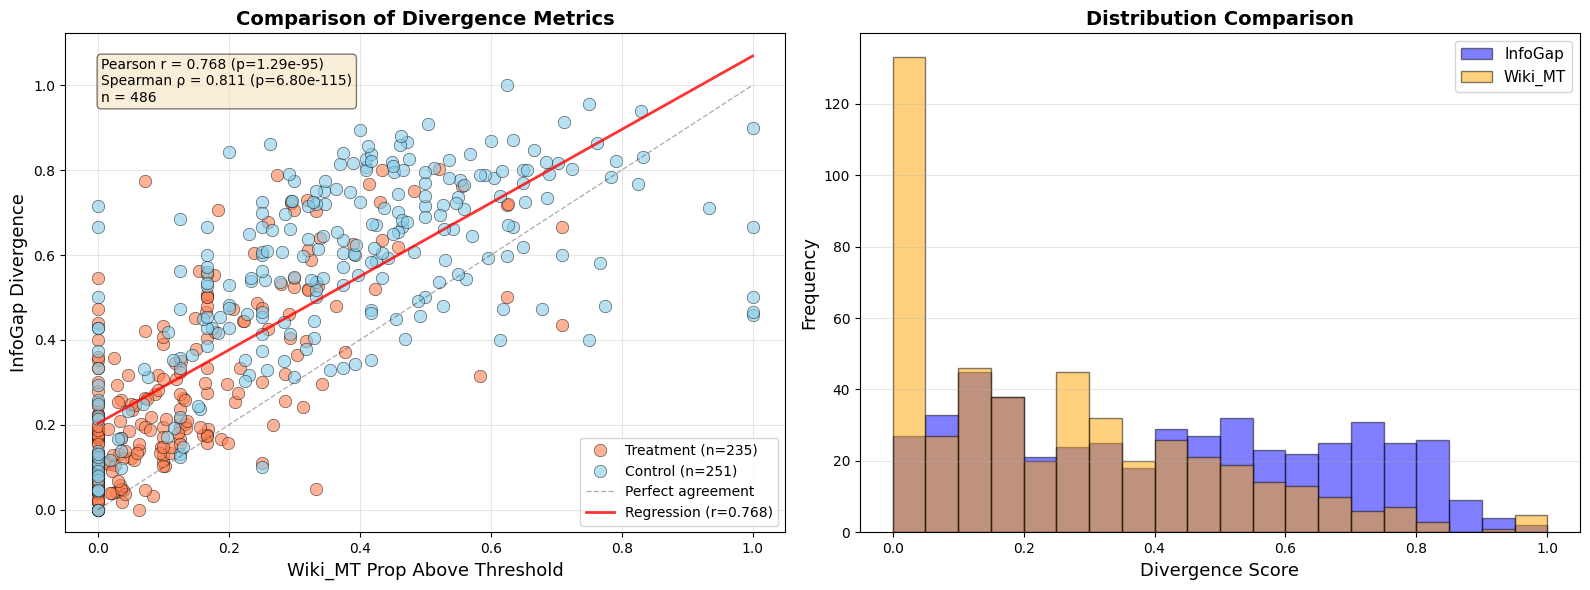

In [41]:
# ==============================================================================
# Correlation Analysis: InfoGap vs Wiki_MT Divergence Metrics
# ==============================================================================

if len(method_comparison_df) > 0:
    print(f"\n{'='*80}")
    print("Correlation Analysis: InfoGap vs Wiki_MT Divergence Metrics")
    print(f"{'='*80}")
    
    # List of Wiki_MT metrics to compare
    wikimt_metrics = [
        ('wikimt_prop_above_threshold', 'Prop Above Threshold'),
        ('wikimt_median_divergence', 'Median Divergence'),
        ('wikimt_upper_percentile', 'Upper Percentile Score')
    ]
    
    results = []
    
    for metric_col, metric_name in wikimt_metrics:
        if metric_col not in method_comparison_df.columns:
            continue
            
        # Clean data (remove NaN values)
        clean_df = method_comparison_df.dropna(subset=['infogap_divergence', metric_col])
        
        if len(clean_df) >= 3:
            from scipy import stats
            
            infogap_scores = clean_df['infogap_divergence']
            wikimt_scores = clean_df[metric_col]
            
            # Pearson correlation
            pearson_r, pearson_p = stats.pearsonr(infogap_scores, wikimt_scores)
            
            # Spearman correlation
            spearman_r, spearman_p = stats.spearmanr(infogap_scores, wikimt_scores)
            
            results.append({
                'metric': metric_name,
                'n': len(clean_df),
                'pearson_r': pearson_r,
                'pearson_p': pearson_p,
                'spearman_r': spearman_r,
                'spearman_p': spearman_p
            })
    
    if results:
        import pandas as pd
        results_df = pd.DataFrame(results)
        
        print(f"\nCorrelation Results:")
        print(results_df.to_string(index=False))
        
        # Find best correlation
        best_idx = results_df['pearson_r'].abs().idxmax()
        best_metric = results_df.iloc[best_idx]
        
        print(f"\n{'='*80}")
        print(f"Best Correlation: {best_metric['metric']}")
        print(f"{'='*80}")
        print(f"  Pearson r = {best_metric['pearson_r']:.4f} (p = {best_metric['pearson_p']:.2e})")
        print(f"  Spearman ρ = {best_metric['spearman_r']:.4f} (p = {best_metric['spearman_p']:.2e})")
        print(f"  Sample size: n = {best_metric['n']}")
        
        # Detailed analysis for prop_above_threshold (main metric)
        metric_col = 'wikimt_prop_above_threshold'
        if metric_col in method_comparison_df.columns:
            clean_df = method_comparison_df.dropna(subset=['infogap_divergence', metric_col])
            
            if len(clean_df) >= 3:
                print(f"\n{'='*80}")
                print("Detailed Analysis: Prop Above Threshold")
                print(f"{'='*80}")
                
                infogap_scores = clean_df['infogap_divergence']
                wikimt_scores = clean_df[metric_col]
                
                # Summary statistics
                print(f"\nInfoGap Divergence:")
                print(f"  Mean: {infogap_scores.mean():.4f}")
                print(f"  Median: {infogap_scores.median():.4f}")
                print(f"  Std: {infogap_scores.std():.4f}")
                print(f"  Range: [{infogap_scores.min():.4f}, {infogap_scores.max():.4f}]")
                
                print(f"\nWiki_MT Prop Above Threshold:")
                print(f"  Mean: {wikimt_scores.mean():.4f}")
                print(f"  Median: {wikimt_scores.median():.4f}")
                print(f"  Std: {wikimt_scores.std():.4f}")
                print(f"  Range: [{wikimt_scores.min():.4f}, {wikimt_scores.max():.4f}]")
                
                # Visualization
                import matplotlib.pyplot as plt
                import seaborn as sns
                import numpy as np
                
                print(f"\n{'='*80}")
                print("Visualization: InfoGap vs Wiki_MT (Prop Above Threshold)")
                print(f"{'='*80}\n")
                
                fig, axes = plt.subplots(1, 2, figsize=(16, 6))
                
                # Scatter plot
                ax = axes[0]
                
                # Color by group if available
                if 'wikimt_group' in clean_df.columns:
                    for group, color in [('treatment', 'coral'), ('control', 'skyblue')]:
                        group_df = clean_df[clean_df['wikimt_group'] == group]
                        ax.scatter(group_df[metric_col], group_df['infogap_divergence'],
                                  alpha=0.6, s=80, c=color, edgecolor='black', linewidth=0.5,
                                  label=f'{group.capitalize()} (n={len(group_df)})')
                else:
                    ax.scatter(wikimt_scores, infogap_scores, alpha=0.6, s=80, 
                              c='steelblue', edgecolor='black', linewidth=0.5)
                
                # Add diagonal line (perfect agreement)
                max_val = max(infogap_scores.max(), wikimt_scores.max())
                min_val = min(infogap_scores.min(), wikimt_scores.min())
                ax.plot([min_val, max_val], [min_val, max_val], 'k--', 
                       alpha=0.3, linewidth=1, label='Perfect agreement')
                
                # Add regression line
                from scipy.stats import linregress
                slope, intercept, r_value, p_value, std_err = linregress(wikimt_scores, infogap_scores)
                x_line = np.linspace(wikimt_scores.min(), wikimt_scores.max(), 100)
                y_line = slope * x_line + intercept
                
                pearson_r, pearson_p = stats.pearsonr(infogap_scores, wikimt_scores)
                ax.plot(x_line, y_line, 'r-', alpha=0.8, linewidth=2, 
                       label=f'Regression (r={pearson_r:.3f})')
                
                ax.set_xlabel('Wiki_MT Prop Above Threshold', fontsize=13)
                ax.set_ylabel('InfoGap Divergence', fontsize=13)
                ax.set_title('Comparison of Divergence Metrics', fontsize=14, fontweight='bold')
                ax.legend(loc='best', fontsize=10)
                ax.grid(True, alpha=0.3)
                
                # Add correlation info
                spearman_r, spearman_p = stats.spearmanr(infogap_scores, wikimt_scores)
                textstr = f'Pearson r = {pearson_r:.3f} (p={pearson_p:.2e})\nSpearman ρ = {spearman_r:.3f} (p={spearman_p:.2e})\nn = {len(clean_df)}'
                ax.text(0.05, 0.95, textstr, transform=ax.transAxes, fontsize=10,
                        verticalalignment='top', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
                
                # Distribution comparison
                ax = axes[1]
                ax.hist(infogap_scores, bins=20, alpha=0.5, label='InfoGap', color='blue', edgecolor='black')
                ax.hist(wikimt_scores, bins=20, alpha=0.5, label='Wiki_MT', color='orange', edgecolor='black')
                ax.set_xlabel('Divergence Score', fontsize=13)
                ax.set_ylabel('Frequency', fontsize=13)
                ax.set_title('Distribution Comparison', fontsize=14, fontweight='bold')
                ax.legend(loc='best', fontsize=11)
                ax.grid(True, alpha=0.3, axis='y')
                
                plt.tight_layout()
                plt.show()
    else:
        print(f"\n⚠️  No Wiki_MT divergence scores available for comparison")
        print("   All Wiki_MT metrics have insufficient data")
else:
    print(f"\n⚠️  No method comparison data available")
    print("   Run the previous cell to create method_comparison_df")